In [69]:
import pandas as pd
import numpy as np
from pathlib import Path

base_path = Path("/Users/Milenka/PycharmProjects/ml-wakacyjne-wyzwanie-2026/01_przetwarzanie_wizualizacja_danych")

# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


# Typy danych

In [70]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId', dtype={'Survived':int, 'Pclass':int, 'Name':object, 'Sex':object, 'Age':float, 'SibSp':int, 'Parch':int, 'Ticket':object, 'Cabin':object, 'Embarked':object})
titanic_df.dtypes

Survived      int64
Pclass        int64
Name         object
Sex          object
Age         float64
SibSp         int64
Parch         int64
Ticket       object
Fare        float64
Cabin        object
Embarked     object
dtype: object

# Brakujące dane

In [71]:
titanic_df.isna().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare         98
Cabin       687
Embarked      2
dtype: int64

In [72]:
#uzupełnienie kolumny Age - zgodnie z rozkładem istniejących danych
def get_column_distribution(df, column):
    return df[column].value_counts(normalize=True)

age_count_prob=get_column_distribution(titanic_df, 'Age')
age_count_prob

age_values=age_count_prob.index
age_probs=age_count_prob.values

missing_age_vals=titanic_df.Age.isna()
titanic_df.loc[missing_age_vals, 'Age']=np.random.choice(age_values, size=missing_age_vals.sum(), p=age_probs)

In [73]:
#uzupełnienie kolumny Fare - zgodnie z rozkładem istniejących danych
fare_count_prob=get_column_distribution(titanic_df, 'Fare')
fare_count_prob

fare_values=fare_count_prob.index
fare_probs=fare_count_prob.values

missing_fare_vals=titanic_df.Fare.isna()
titanic_df.loc[missing_fare_vals, 'Fare']=np.random.choice(fare_values, size=missing_fare_vals.sum(), p=fare_probs)

In [74]:
#uzupełnienie kolumny Embarked - najczęstsza wartość (moda)
titanic_df['Embarked']=titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0])

zamiana kolumny Cabin na Deck i uzupełnienie danych w następnej sekcji

# Dodanie (zamienienie) kolumn
- pełne imię i nazwisko nie będzie użyteczne, ale wyodrębnię tytuł (dużo unikalnych wartości)
- pełny numer biletu również ma dużo unikalnych wartości, wyodrębnię więc początek (sekcję)
- tak samo robię z numerem kabiny, zostawiam tylko pierwszą literkę (tam, gdzie brakowało Cabin, Deck to Unknown)

In [75]:
#zamienienie kolumny Name na Title poprzez wyodrębnienie tytułu z kolumny Name
titanic_df['Name']=titanic_df['Name'].str.extract(r',\s([^\.]+)\.')
titanic_df=titanic_df.rename(columns={'Name':'Title'})

In [76]:
#dodanie kolumny FamilySize (wielkość rodziny)
titanic_df['FamilySize']=titanic_df['SibSp']+titanic_df['Parch']+1

In [77]:
#zamienienie kolumny Ticket na TicketType poprzez wyodrębnienie "prefiksu" numeru biletu
titanic_df['Ticket']=titanic_df['Ticket'].str.split(' ').str[0]
titanic_df.loc[titanic_df['Ticket'].str.isdigit(), 'Ticket']='None'
titanic_df=titanic_df.rename(columns={'Ticket':'TicketType'})

In [78]:
#zamienienie kolumny Cabin na Deck poprzez zredukowanie wartości z kolumny Cabin do pierwszej litery
titanic_df['Cabin']=titanic_df['Cabin'].str[0]
titanic_df=titanic_df.rename(columns={'Cabin':'Deck'})

#uzupełnianie kolumny Deck - "Unknown"
titanic_df['Deck']=titanic_df['Deck'].fillna('Unknown')

# Outliery

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

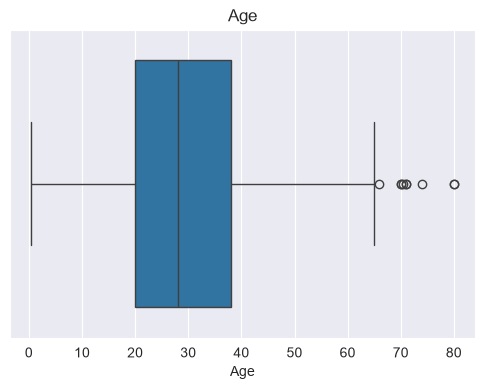

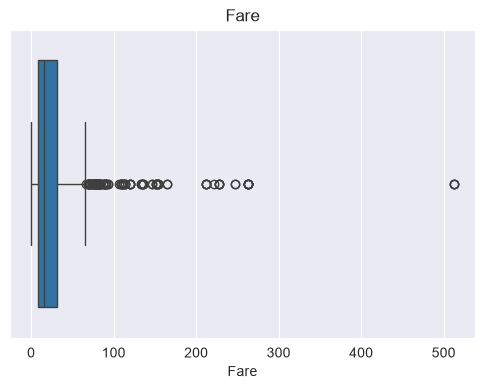

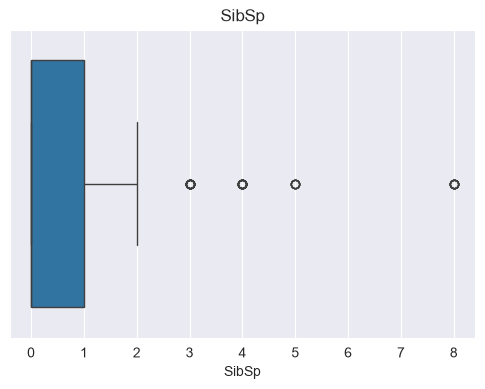

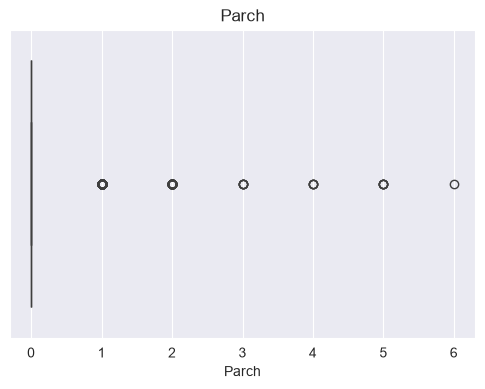

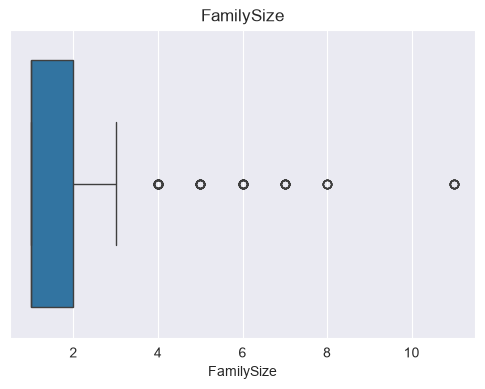

In [80]:
#dla danych numerycznych
for column in ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize']:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=titanic_df[column])
    plt.title(column)
    plt.show()

#### dla Age
pojedyncze skrajne wartości nie muszą być błędami
#### dla Fare
wyraźne wartości skrajne, ale mogą być faktycznymi cenami
#### dla SibSp, Parch i FamilySize
są wartości skrajne, jednak są realne

In [81]:
#dla danych kategorialnych
for column in ['Title', 'Sex', 'Embarked', 'Deck', 'TicketType']:
    print('\n', column)
    print(titanic_df[column].value_counts())


 Title
Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

 Sex
Sex
male      577
female    314
Name: count, dtype: int64

 Embarked
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

 Deck
Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

 TicketType
TicketType
None          661
PC             60
C.A.           27
STON/O         12
A/5            10
W./C.           9
SOTON/O.Q.      8
CA.             8
A/5.            7
SOTON/OQ        7
STON/O2.        6
CA              6
S.O.C.          5
C               5
SC/PARIS        5
F.C.C.          

Występują rzadkie wartości w Title i TicketType, zostaną one połączone przeze mnie w kategorię Rare.

# Rozkład zmiennej predykowanej względem zmiennych kategorialnych i numerycznych

In [82]:
#łączę rzadko występujące tytuły w kategorię Rare
title_counts=titanic_df['Title'].value_counts()
rare_titles=title_counts[title_counts<10].index
titanic_df['Title']=titanic_df['Title'].replace(rare_titles, 'Rare')

In [83]:
#łączę rzadko występujące typy biletów w kategorię Rare
ticket_counts=titanic_df['TicketType'].value_counts()
rare_tickets=ticket_counts[ticket_counts<10].index
titanic_df['TicketType']=titanic_df['TicketType'].replace(rare_tickets, 'Rare')

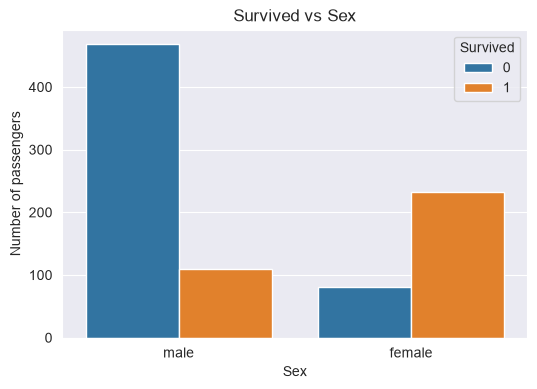

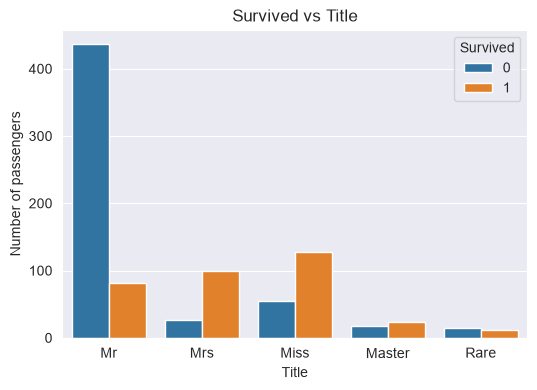

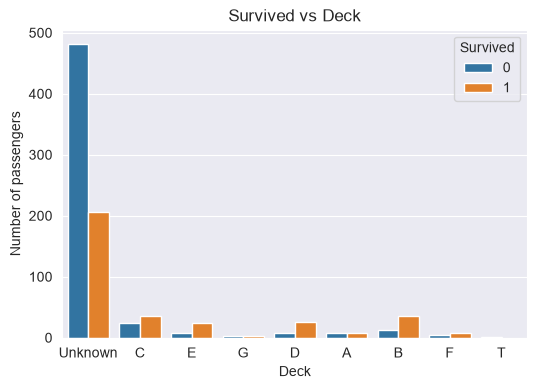

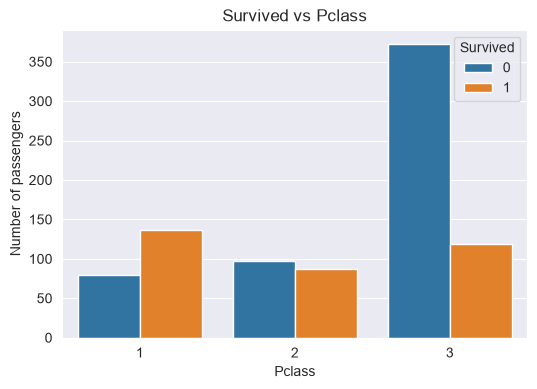

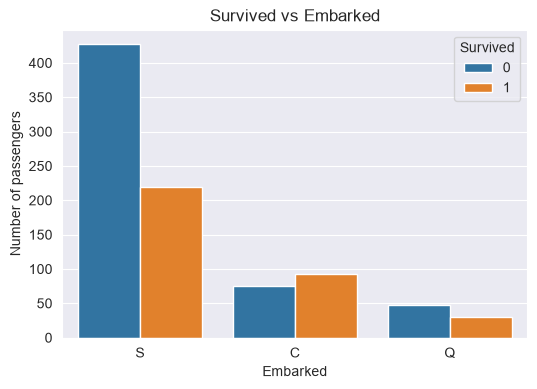

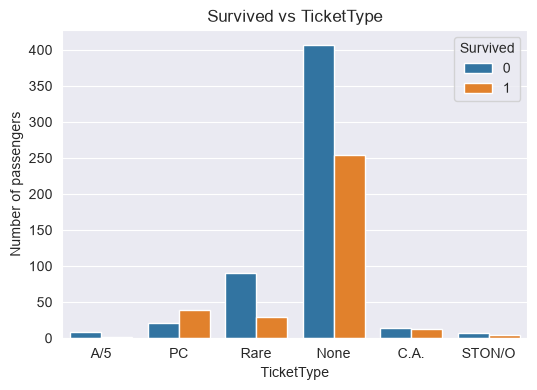

In [84]:
#survived względem zmiennych kategorialnych
categorical=['Sex', 'Title', 'Deck', 'Pclass', 'Embarked', 'TicketType']

for column in categorical:
    plt.figure(figsize=(6,4))
    sns.countplot(data=titanic_df, x=column, hue='Survived')
    plt.title(f'Survived vs {column}')
    plt.xlabel(column)
    plt.ylabel('Number of passengers')
    plt.show()

#### Sex vs Survived
wyraźna zależność - dla kobiet odsetek osób, które przeżyły jest znacznie większy niż odsetek ofiar, a dla mężczyzn jest odwrotnie
płeć może mieć znaczący wpływ na przewidywanie przeżycia pasażera

#### Title vs Survived
potwierdzają się wnioski z poprzedniego punktu, znacznie większa przeżywalność dla osób o tytułach żeńskich

#### Deck vs Survived
osoby, których numer kabiny nie jest znany, przeżywały rzadziej niż osoby, których numer kabiny jest znany

#### Pclass vs Survived
największy odsetek osób, które przeżyły, jest w klasie 1, najmniejszy w klasie 3

#### Embarked vs Survived
największy odsetek osób, które przeżyły, wsiadło w C, najmniejszy w S

#### TicketType vs Survived
największy odsetek osób, które przeżyły, miało bilet o numerze rozpoczynającym się od PC

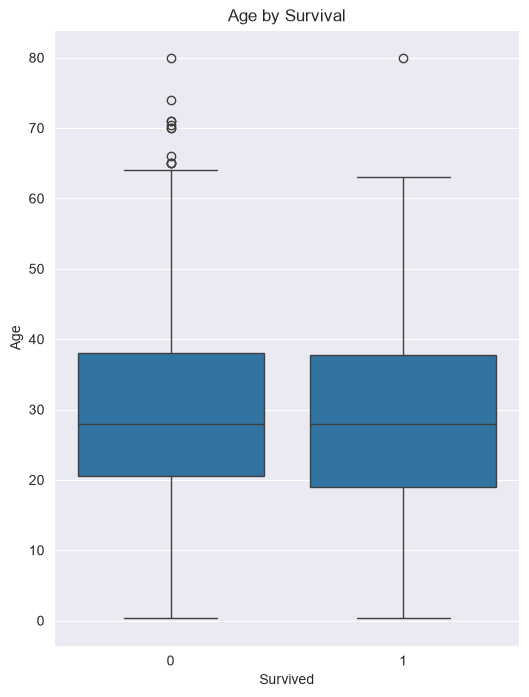

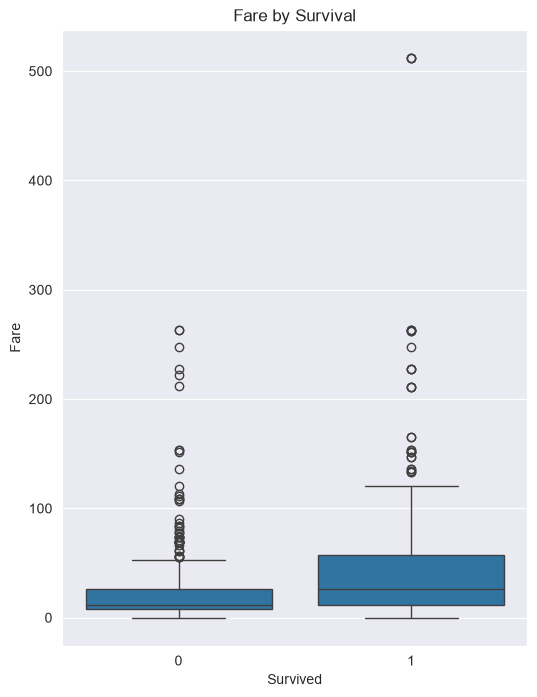

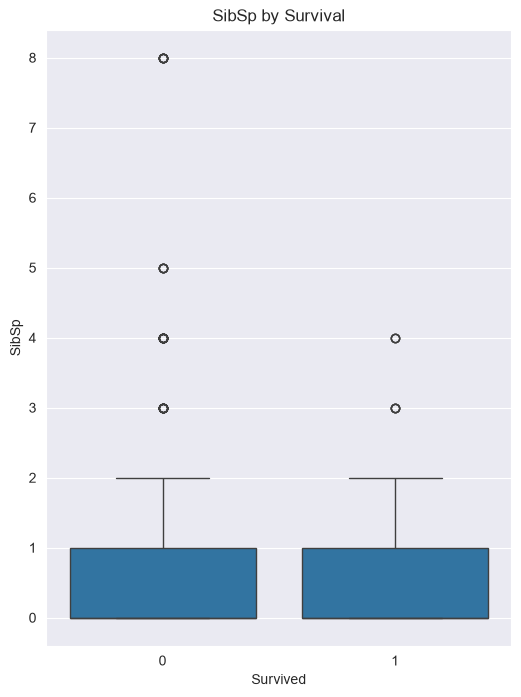

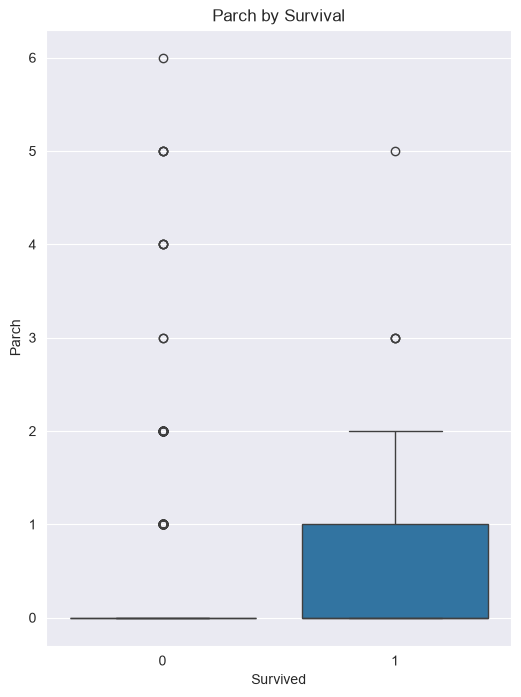

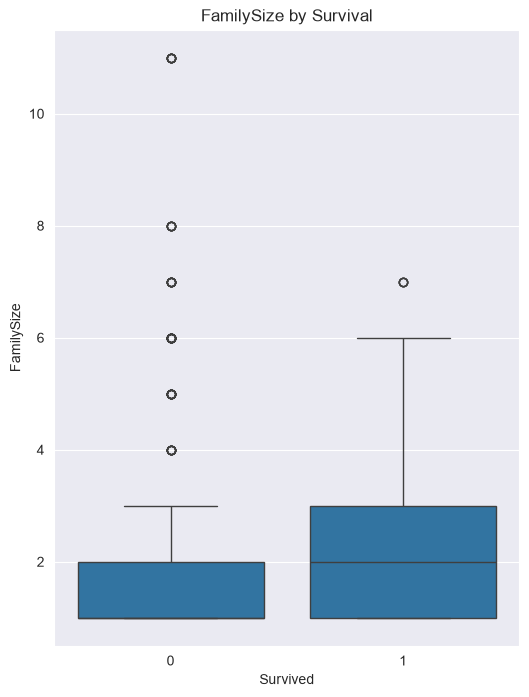

In [85]:
#survived względem zmiennych numerycznych
numeric=['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize']

for column in numeric:
    plt.figure(figsize=(6,8))
    sns.boxplot(data=titanic_df, x='Survived', y=column)

    plt.title(f'{column} by Survival')
    plt.xlabel('Survived')
    plt.ylabel(column)
    plt.show()

#### dla Age
brak wyraźnej zależności, można pokusić się o stwierdzenie, że młodsze osoby przeżywały częściej

#### dla Fare
mediana ceny biletu dla osób, które przeżyły, jest większa niż mediana ceny biletu dla ofiar, więc im wyższa cena, tym większa przeżywalność (prawdopodobnie związane z klasami, w 1 przeżywalność była największa)

#### dla SibSp
brak zależności

#### dla Parch
posiadanie większej liczby rodziców/dzieci na pokładzie było częstsze u osób, które przeżyły

#### dla FamilySize
wśród ocalałych większe zróżnicowanie wielkości rodzin, osoby z większą rodziną przeżywały częściej

# Kodowanie kolumn

In [ ]:
titanic_df.dtypes
columns_to_code=titanic_df.select_dtypes(include='object').columns.tolist()
columns_to_code

In [87]:
#kodowanie kolumny Pclass
title_counts=titanic_df['Pclass'].value_counts()

titanic_df=pd.get_dummies(data=titanic_df, prefix='Pclass', columns=['Pclass'], dtype=int)

In [88]:
#kodowanie kolumny Title
title_counts=titanic_df['Title'].value_counts()

titanic_df=pd.get_dummies(data=titanic_df, prefix='Title', columns=['Title'], dtype=int)

In [89]:
#kodowanie kolumny Sex
sex_counts=titanic_df['Sex'].value_counts()
titanic_df=pd.get_dummies(data=titanic_df, prefix='Sex', columns=['Sex'], dtype=int)

In [90]:
#kodowanie kolumny TicketType
ticket_counts=titanic_df['TicketType'].value_counts()

titanic_df=pd.get_dummies(data=titanic_df, prefix='TicketType', columns=['TicketType'], dtype=int)

In [91]:
#kodowanie kolumny Deck
deck_counts=titanic_df['Deck'].value_counts()

titanic_df=pd.get_dummies(data=titanic_df, prefix='Deck', columns=['Deck'], dtype=int)

In [92]:
#kodowanie kolumny Embarked
embarked_counts = titanic_df['Embarked'].value_counts()

titanic_df = pd.get_dummies(data=titanic_df, prefix='Embarked', columns=['Embarked'], dtype=int)

# Wizualizacja danych

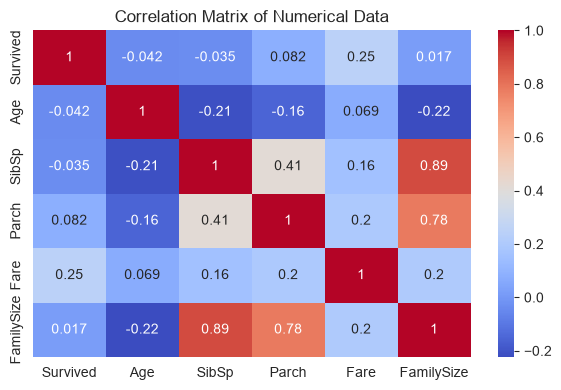

In [93]:
#dla danych numerycznych
numerical=['Survived', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']

corr_matrix=titanic_df[numerical].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Data')
plt.tight_layout()
plt.show()

#### Fare
najbardziej dodatnio skorelowane z Survived, potwierdzają się wcześniejsze wnioski
kluczowa zmienna numeryczna do przewidywania przeżycia

#### Parch
lekko dodatnia korelacja Parch z Survived, potwierdzają się wcześniejsze wnioski

#### Age
lekko ujemna korelacja Age z Survived, potwierdzają się poprzednie wnioski
ujemne korelacje z Parch, SibSp, FamilySize (młodzi częściej podróżowali z rodziną, starsi częściej w pojedynkę)



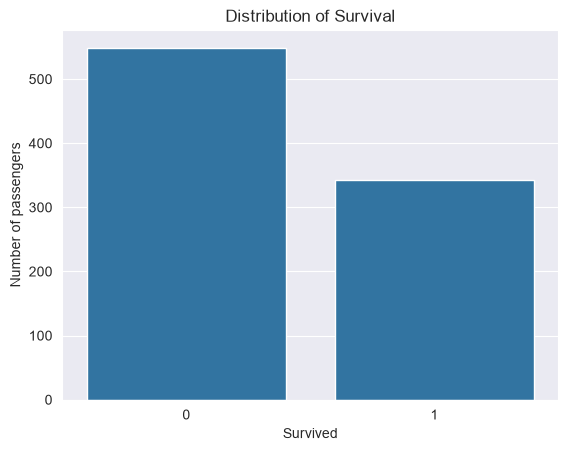

In [94]:
sns.countplot(data=titanic_df, x='Survived')
plt.title('Distribution of Survival')
plt.xlabel('Survived')
plt.ylabel('Number of passengers')
plt.show()

# Dystrybucja danych

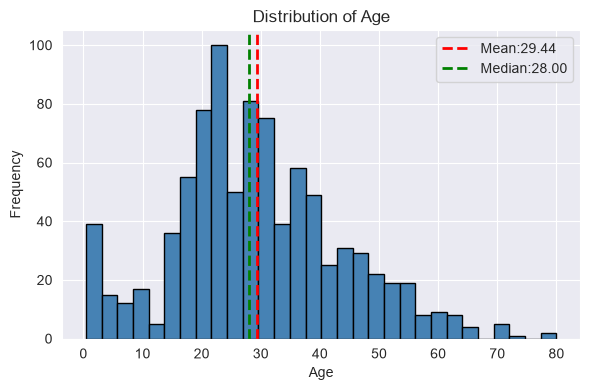

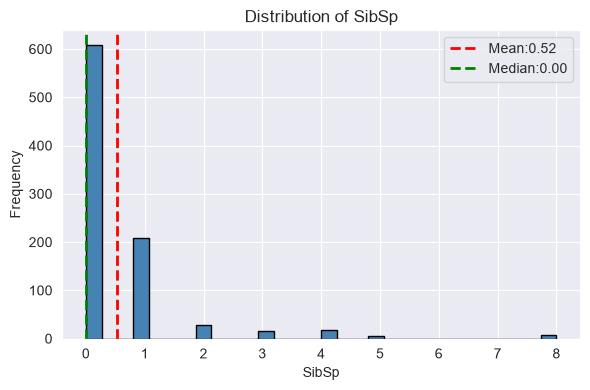

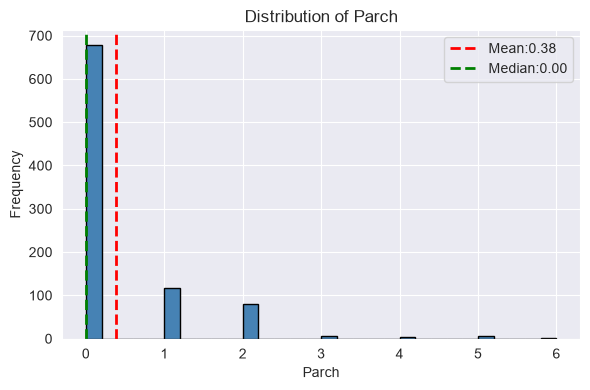

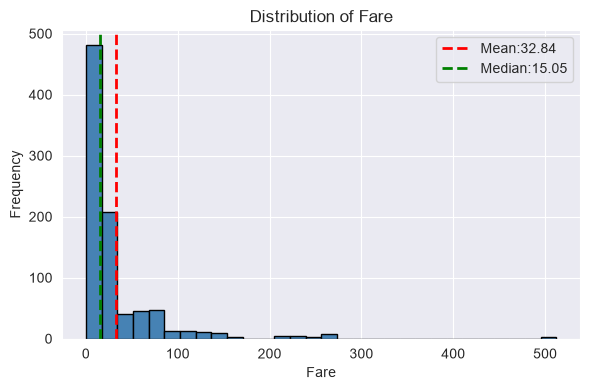

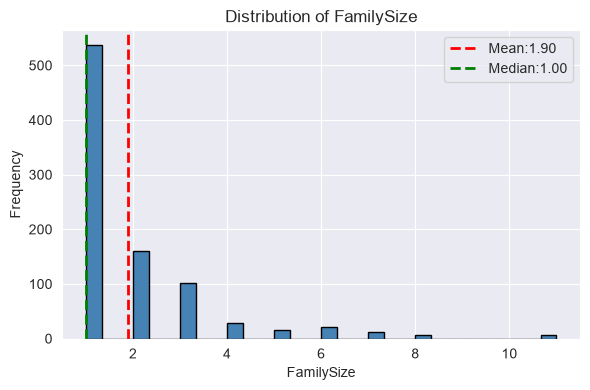

In [95]:
def plot_numeric_histogram(df, column_name):

    data=df[column_name]
    mean_val=data.mean()
    median_val=data.median()

    plt.figure(figsize=(6,4))
    plt.hist(data, bins=30, color='steelblue', edgecolor='black')
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean:{mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median:{median_val:.2f}')

    plt.title(f'Distribution of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_numeric_histogram(titanic_df, 'Age') #rozkład asymetryczny prawostronnie (lekko)
plot_numeric_histogram(titanic_df, 'SibSp') #rozkład asymetryczny prawostronnie (silnie)
plot_numeric_histogram(titanic_df, 'Parch') #rozkład asymetryczny prawostronnie (silnie)
plot_numeric_histogram(titanic_df, 'Fare') #rozkład asymetryczny prawostronnie (silnie)
plot_numeric_histogram(titanic_df, 'FamilySize') #rozkład asymetryczny prawostronnie (silnie)

